# Quantitative Risk & Portfolio Dashboard

Objective: Analyze the risk/return profile of a tech portfolio (AAPL, MSFT, GOOGL) and optimize asset allocation using Monte Carlo simulations.

Key Metrics:

Sharpe Ratio Optimization: Identifying the efficient frontier.

Value at Risk (VaR): quantifying tail risk at 95% confidence.

Maximum Drawdown: Stress-testing portfolio resilience.

In [1]:
#1. SETUP & IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
#2. DEFINE HELPER FUNCTIONS

def calculate_drawdown(series):
    cumulative = (1 + series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    return drawdown, drawdown.min()

def calculate_var(series, confidence_level=0.05):
    return np.percentile(series, confidence_level * 100)

def simulate_portfolios(daily_returns, num_portfolios=1000):
    
    np.random.seed(42)
    results = np.zeros((3, num_portfolios))
    weights_record = []
    cov_matrix = daily_returns.cov() * 252
    
    for i in range(num_portfolios):
        weights = np.random.random(len(daily_returns.columns))
        weights /= np.sum(weights)
        weights_record.append(weights)
        portfolio_return = np.sum(weights * daily_returns.mean()) * 252
        portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        results[0,i] = portfolio_return
        results[1,i] = portfolio_std_dev
        results[2,i] = results[0,i] / results[1,i]
        
    max_sharpe_idx = np.argmax(results[2])
    best_weights = weights_record[max_sharpe_idx]
    return results, best_weights, max_sharpe_idx

In [3]:
#3. DATA INGESTION
tickers = ['AAPL', 'MSFT', 'GOOGL']
print(f"Downloading data for: {tickers}...")
df = yf.download(tickers, start='2023-01-01', auto_adjust=False)['Adj Close']

daily_returns = df.pct_change().dropna()
print("Data loaded and returns calculated.")
print(df.tail())

[*********************100%***********************]  3 of 3 completed

Data loaded and returns calculated.
Ticker            AAPL       GOOGL        MSFT
Date                                          
2026-01-16  255.529999  330.000000  459.859985
2026-01-20  246.699997  322.000000  454.519989
2026-01-21  247.649994  328.380005  444.109985
2026-01-22  248.350006  330.540009  451.140015
2026-01-23         NaN  327.779999         NaN



C:\Users\viraj\AppData\Local\Temp\ipykernel_53956\1511061234.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = df.pct_change().dropna()


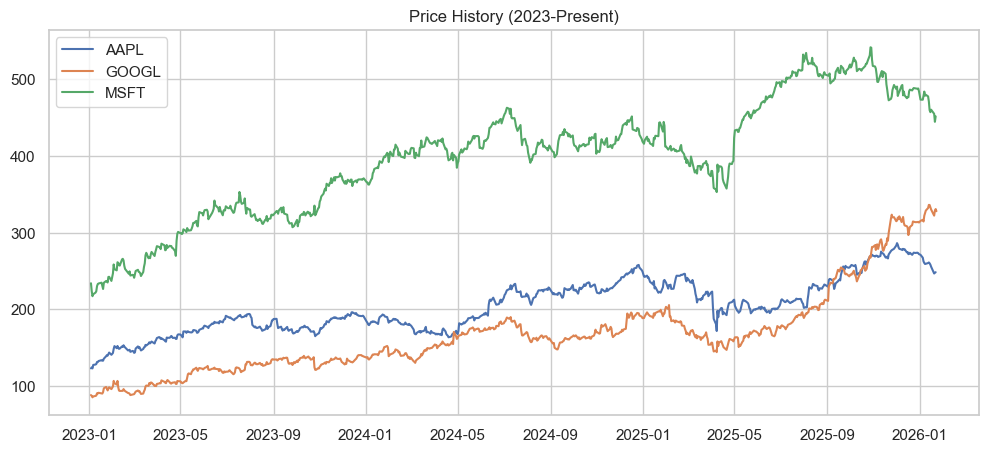

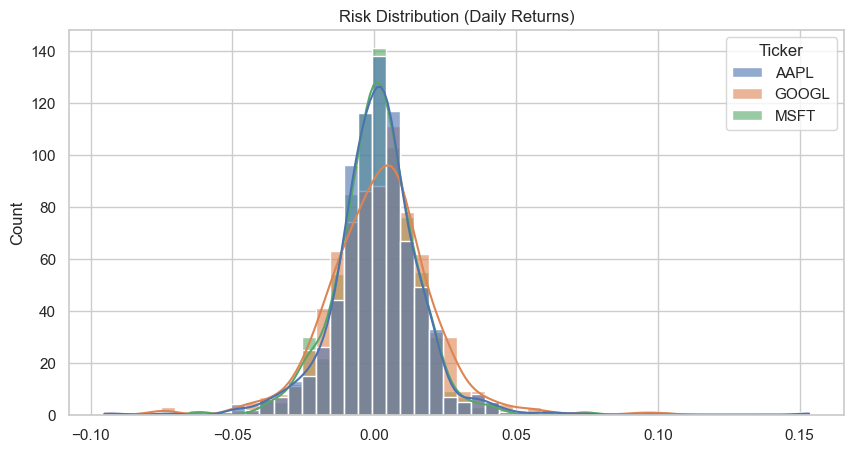

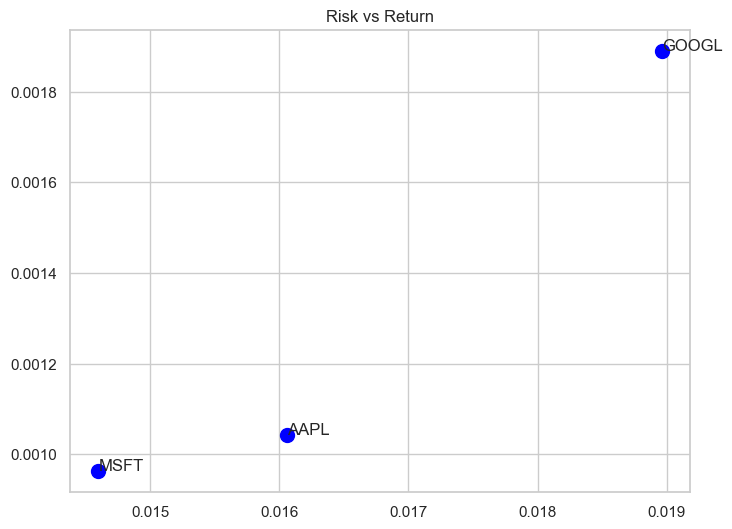

In [4]:
#4. EXPLORATORY ANALYSIS


plt.figure(figsize=(12, 5))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)
plt.title("Price History (2023-Present)")
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
sns.histplot(daily_returns, bins=50, kde=True, alpha=0.6)
plt.title("Risk Distribution (Daily Returns)")
plt.show()


avg_daily_ret = daily_returns.mean()
risk = daily_returns.std()
plt.figure(figsize=(8, 6))
plt.scatter(risk, avg_daily_ret, s=100, color='blue')
for ticker in tickers:
    plt.text(risk[ticker], avg_daily_ret[ticker], ticker, fontsize=12)
plt.title('Risk vs Return')
plt.grid(True)
plt.show()

Raw prices can be noisy. To identify the true trend, I'll overlay a 30-day Simple Moving Average (SMA) to dampen daily volatility.

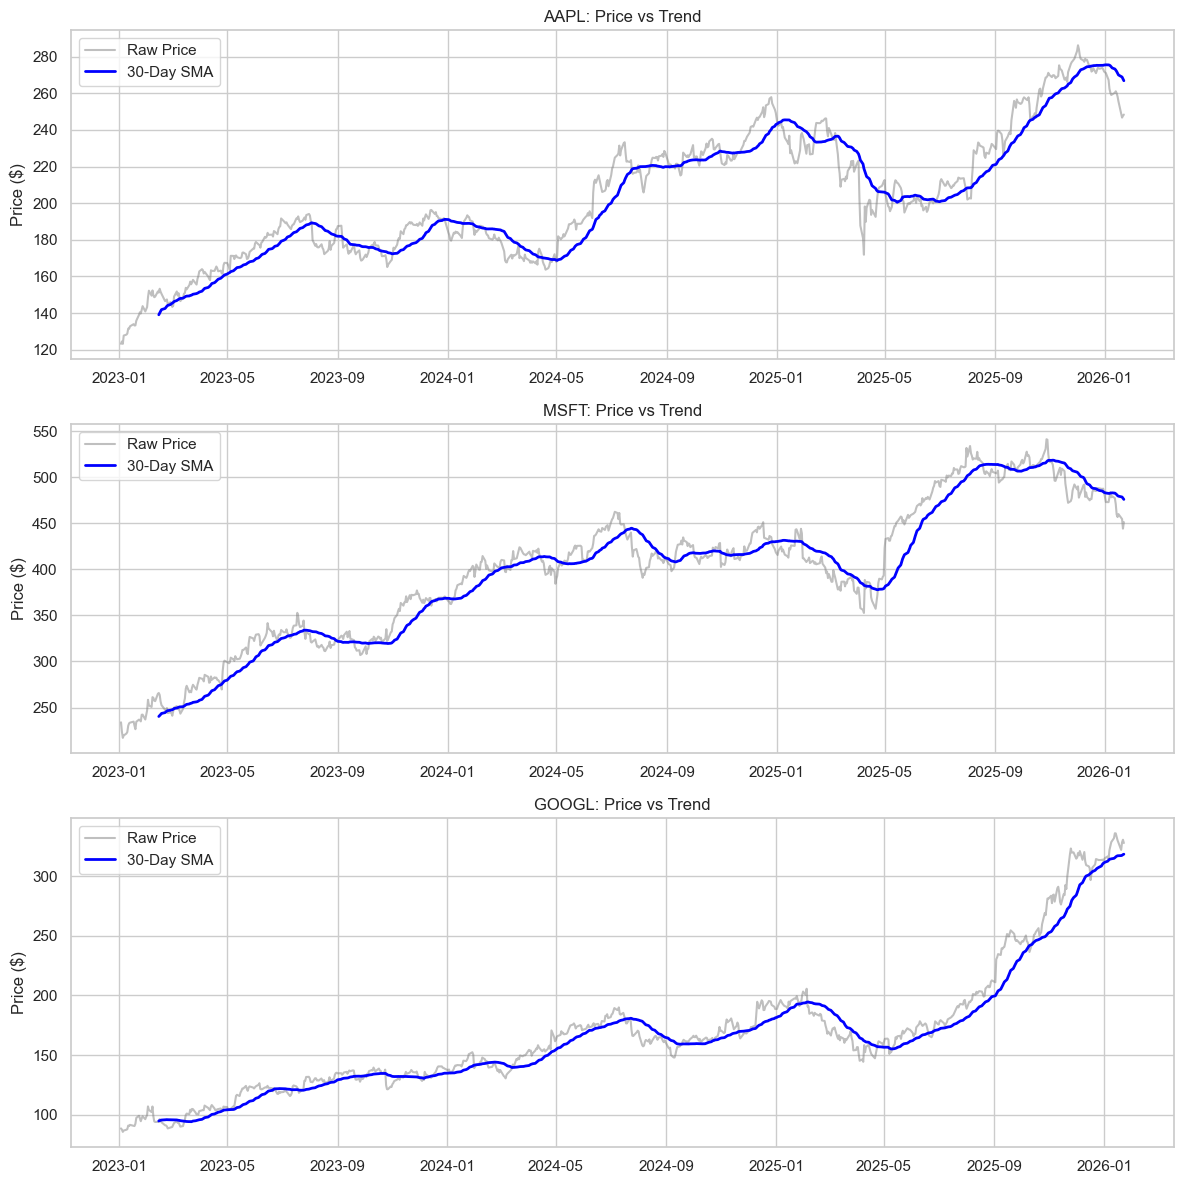

In [5]:
#5. TECHNICAL INDICATORS 

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, ticker in enumerate(tickers):
    
    sma = df[ticker].rolling(window=30).mean()
    
   
    axes[i].plot(df.index, df[ticker], label='Raw Price', color='gray', alpha=0.5)
    axes[i].plot(df.index, sma, label='30-Day SMA', color='blue', linewidth=2)
    
  
    axes[i].set_title(f'{ticker}: Price vs Trend')
    axes[i].set_ylabel('Price ($)')
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

Looking at the historical returns, it's unclear what the optimal mix is. A simple 50/30/20 split is a guess. To find the mathematically optimal portfolio, I will simulate 1,000 random weight combinations to map the Efficient Frontier.

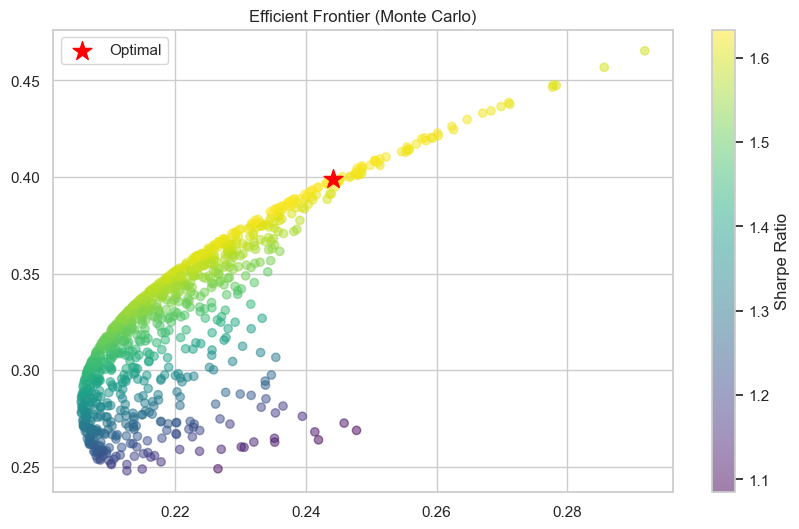

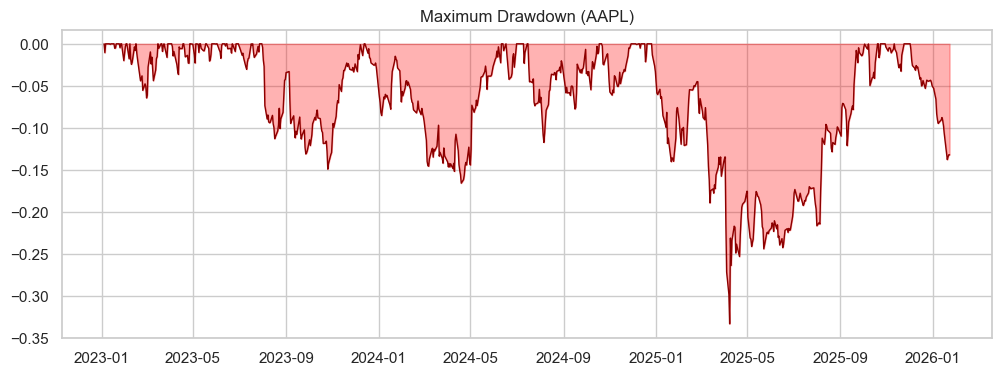

In [6]:
#6. Advanced Modeling


results, best_weights, max_idx = simulate_portfolios(daily_returns)

plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(results[1,max_idx], results[0,max_idx], c='red', s=200, marker='*', label='Optimal')
plt.title('Efficient Frontier (Monte Carlo)')
plt.legend()
plt.show()


drawdown, min_dd = calculate_drawdown(daily_returns['AAPL'])

plt.figure(figsize=(12, 4))
plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
plt.plot(drawdown.index, drawdown, color='darkred', lw=1)
plt.title("Maximum Drawdown (AAPL)")
plt.show()

In [7]:
#7. FINAL REPORT 
aapl_var = calculate_var(daily_returns['AAPL'])

print("\n" + "="*40)
print("PORTFOLIO OPTIMIZATION REPORT")
print("="*40)
print(f"Optimal Allocation: {dict(zip(tickers, np.round(best_weights, 2)))}")
print(f"Best Sharpe Ratio: {results[2, max_idx]:.2f}")
print("-" * 40)
print(f"AAPL Stress Test:")
print(f"  - Max Drawdown: {min_dd:.2%}")
print(f"  - VaR (95%): {aapl_var:.2%}")
print("="*40)


PORTFOLIO OPTIMIZATION REPORT
Optimal Allocation: {'AAPL': np.float64(0.17), 'MSFT': np.float64(0.65), 'GOOGL': np.float64(0.17)}
Best Sharpe Ratio: 1.63
----------------------------------------
AAPL Stress Test:
  - Max Drawdown: -33.36%
  - VaR (95%): -2.41%


--- Simulating 1,000 Portfolios ---
Best Portfolio: [0.17356365 0.6525958  0.17384055]
Best Return: 0.39876568406661994
Best Risk: 0.2441501205730245


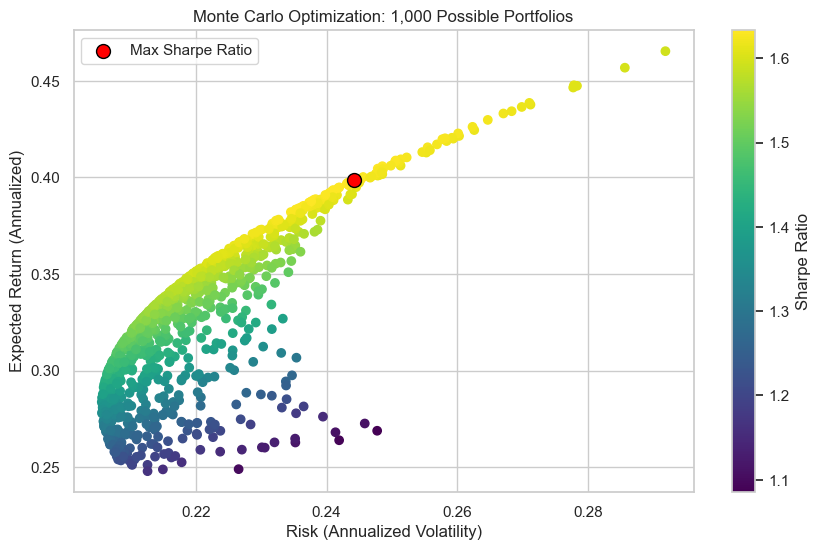

In [8]:
#8. MONTE CARLO OPTIMIZATION 

print("--- Simulating 1,000 Portfolios ---")
np.random.seed(42) 


p_ret = [] 
p_vol = [] 
p_weights = [] 

num_assets = len(df.columns)
num_portfolios = 1000


cov_matrix = daily_returns.cov() * 252  

for i in range(num_portfolios):
   
    weights = np.random.random(num_assets)
    weights /= np.sum(weights) # Normalize to sum to 1.0
    p_weights.append(weights)
    
  
    returns = np.sum(weights * daily_returns.mean()) * 252
    p_ret.append(returns)
    
  
    var = np.dot(weights.T, np.dot(cov_matrix, weights))
    sd = np.sqrt(var)
    p_vol.append(sd)


p_ret = np.array(p_ret)
p_vol = np.array(p_vol)
p_weights = np.array(p_weights)


sharpe_arr = p_ret / p_vol
max_sr_index = sharpe_arr.argmax() 

print("Best Portfolio:", p_weights[max_sr_index])
print("Best Return:", p_ret[max_sr_index])
print("Best Risk:", p_vol[max_sr_index])


plt.figure(figsize=(10, 6))

plt.scatter(p_vol, p_ret, c=sharpe_arr, cmap='viridis') 
plt.colorbar(label='Sharpe Ratio')

plt.scatter(p_vol[max_sr_index], p_ret[max_sr_index], c='red', s=100, edgecolors='black', label='Max Sharpe Ratio')

plt.title('Monte Carlo Optimization: 1,000 Possible Portfolios')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Return (Annualized)')
plt.legend()
plt.show()

Conclusion & Future Improvements

While the simulation successfully identified an optimal Sharpe Ratio, this model relies on historical data (2023-Present) which may not predict future black swan events.

Future iterations will include:

Dynamic Rebalancing: Simulating trades to maintain target weights over time.

Transaction Costs: Factoring in the fees of buying/selling to see if the strategy is still profitable.

Live Dashboard: Deploying this analysis using Streamlit for interactive user testing.